In [2]:
# Cell 1: Imports & Settings
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import random

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Fix randomness
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
SOURCE_DIR = r"D:\Final Project\Buildable-ML-DL-Fellowship\Final_project\data\PlantVillage"
DEST_DIR   = r"D:\Final Project\Buildable-ML-DL-Fellowship\Final_project\data\PlantVillage_Split"
MODEL_DIR  = "models"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DEST_DIR, exist_ok=True)

print("Source:", SOURCE_DIR)
print("Destination:", DEST_DIR)


Source: D:\Final Project\Buildable-ML-DL-Fellowship\Final_project\data\PlantVillage
Destination: D:\Final Project\Buildable-ML-DL-Fellowship\Final_project\data\PlantVillage_Split


In [4]:
def create_train_val_test(src_root, dst_root, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    random.seed(seed)

    classes = [d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))]
    print("Detected classes:", classes)

    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(dst_root, split), exist_ok=True)

    for cls in classes:
        src_cls_dir = os.path.join(src_root, cls)
        images = [f for f in os.listdir(src_cls_dir)
                  if f.lower().endswith((".jpg", ".png", ".jpeg"))]

        random.shuffle(images)

        total = len(images)
        n_train = int(total * train_ratio)
        n_val = int(total * val_ratio)

        train_files = images[:n_train]
        val_files   = images[n_train:n_train+n_val]
        test_files  = images[n_train+n_val:]

        for split, files in zip(["train", "val", "test"], [train_files, val_files, test_files]):
            split_dir = os.path.join(dst_root, split, cls)
            os.makedirs(split_dir, exist_ok=True)

            for img in files:
                src = os.path.join(src_cls_dir, img)
                dst = os.path.join(split_dir, img)
                shutil.copy(src, dst)

        print(f"[OK] {cls}: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)})")

    print("\nDataset splitting completed successfully!")


In [5]:
create_train_val_test(SOURCE_DIR, DEST_DIR)


Detected classes: ['Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Leaf_Mold', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Early_blight', 'Tomato_Bacterial_spot', 'Tomato_Late_blight', 'Pepper__bell___healthy', 'Potato___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Pepper__bell___Bacterial_spot']
[OK] Tomato__Target_Spot: Train=982, Val=210, Test=212)
[OK] Tomato__Tomato_mosaic_virus: Train=261, Val=55, Test=57)
[OK] Tomato__Tomato_YellowLeaf__Curl_Virus: Train=2245, Val=481, Test=482)
[OK] Tomato_Leaf_Mold: Train=666, Val=142, Test=144)
[OK] Tomato_Spider_mites_Two_spotted_spider_mite: Train=1173, Val=251, Test=252)
[OK] Tomato_Septoria_leaf_spot: Train=1239, Val=265, Test=267)
[OK] Tomato_healthy: Train=1113, Val=238, Test=240)
[OK] Tomato_Early_blight: Train=700, Val=150, Test=150)
[OK] Tomato_Bacterial_spot: Train=1488, Val=319, Test=320)
[OK] Tomato_Late_

In [6]:
for split in ["train", "val", "test"]:
    split_dir = os.path.join(DEST_DIR, split)
    classes = sorted([d for d in os.listdir(split_dir)])
    print(f"{split} classes:", classes)

    counts = {c: len(os.listdir(os.path.join(split_dir, c))) for c in classes}
    print(f"{split} counts:", counts, "\n")


train classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
train counts: {'Pepper__bell___Bacterial_spot': 697, 'Pepper__bell___healthy': 1034, 'Potato___Early_blight': 700, 'Potato___Late_blight': 700, 'Potato___healthy': 106, 'Tomato_Bacterial_spot': 1488, 'Tomato_Early_blight': 700, 'Tomato_Late_blight': 1336, 'Tomato_Leaf_Mold': 666, 'Tomato_Septoria_leaf_spot': 1239, 'Tomato_Spider_mites_Two_spotted_spider_mite': 1173, 'Tomato__Target_Spot': 982, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 2245, 'Tomato__Tomato_mosaic_virus': 261, 'Tomato_healthy': 1113} 

val classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy'

In [4]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=(0.8,1.2),
    preprocessing_function=effnet_preprocess
)

val_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)
test_datagen = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DEST_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(DEST_DIR, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(DEST_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
print("Detected classes:", train_generator.class_indices)


Found 14440 images belonging to 15 classes.
Found 3089 images belonging to 15 classes.
Found 3109 images belonging to 15 classes.
Detected classes: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


In [5]:
def build_simple_cnn(input_shape=(224,224,3), num_classes=num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_simple_cnn()
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,787,471 (98.37 MB)

 Trainable params: 25,787,471 (98.37 MB)

 Non-trainable params: 0 (0.00 B)

# CNN

In [7]:
callbacks_cnn = [
    callbacks.ModelCheckpoint("models/disease_cnn.h5", save_best_only=True, monitor="val_loss"),
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1
)


452/452 ━━━━━━━━━━━━━━━━━━━━ 1052s 2s/step - accuracy: 0.4044 - loss: 1.8801 - val_accuracy: 0.5623 - val_loss: 1.3591


In [ ]:
cnn_model.save("models/disease_cnn.h5")
print("CNN model saved successfully!")


CNN model saved successfully!


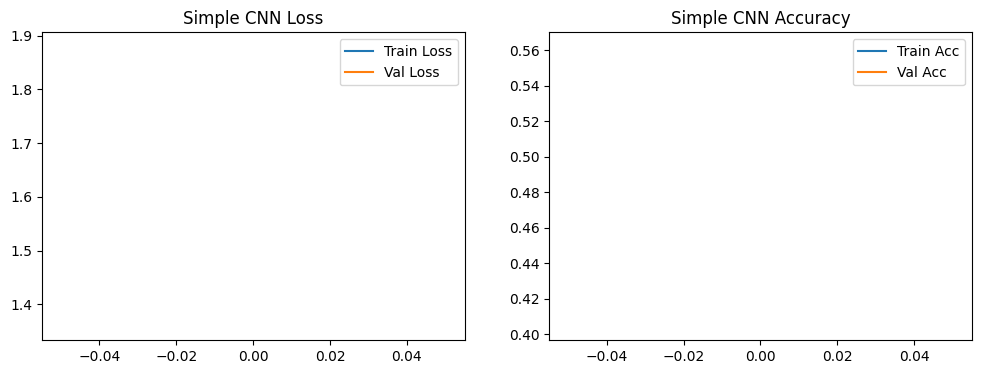

In [10]:
def plot_history(history, title=""):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(title + " Accuracy")
    plt.legend()

    plt.show()

plot_history(history_cnn, "Simple CNN")


In [ ]:
best_cnn = tf.keras.models.load_model("models/disease_cnn.h5")

test_steps = test_generator.samples // test_generator.batch_size + 1
pred = best_cnn.predict(test_generator, steps=test_steps)
y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=train_generator.class_indices.keys()))


98/98 ━━━━━━━━━━━━━━━━━━━━ 43s 425ms/step
Test Accuracy: 0.5648118366034095
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.36      0.53      0.43       151
                     Pepper__bell___healthy       0.66      0.75      0.71       223
                      Potato___Early_blight       0.66      0.54      0.60       150
                       Potato___Late_blight       0.56      0.06      0.11       150
                           Potato___healthy       0.00      0.00      0.00        24
                      Tomato_Bacterial_spot       0.88      0.52      0.65       320
                        Tomato_Early_blight       0.37      0.12      0.18       150
                         Tomato_Late_blight       0.75      0.38      0.50       287
                           Tomato_Leaf_Mold       0.57      0.32      0.41       144
                  Tomato_Septoria_leaf_spot       0.40      0.52      0.4

C:\Users\Ahsan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ahsan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Ahsan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classificati

In [18]:
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

transfer_model = models.Model(inputs, outputs)
transfer_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
transfer_model.summary()


RemoteDisconnected: Remote end closed connection without response

Epoch 1/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 301s 607ms/step - accuracy: 0.6695 - loss: 1.0809 - val_accuracy: 0.9200 - val_loss: 0.2839
Epoch 2/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 239s 529ms/step - accuracy: 0.8917 - loss: 0.3374 - val_accuracy: 0.9136 - val_loss: 0.2474
Epoch 3/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 240s 531ms/step - accuracy: 0.9124 - loss: 0.2597 - val_accuracy: 0.9356 - val_loss: 0.1864
Epoch 4/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 532ms/step - accuracy: 0.9285 - loss: 0.2126 - val_accuracy: 0.9466 - val_loss: 0.1665
Epoch 5/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 243s 538ms/step - accuracy: 0.9336 - loss: 0.1899 - val_accuracy: 0.9204 - val_loss: 0.2237
Epoch 6/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 532ms/step - accuracy: 0.9354 - loss: 0.1794 - val_accuracy: 0.9595 - val_loss: 0.1270
Epoch 7/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 532ms/step - accuracy: 0.9427 - loss: 0.1597 - val_accuracy: 0.9443 - val_loss: 0.1701
Epoch 8/8
452/452 ━━━━━━━━━━━━━━━━━━━━ 242s 536ms/step - accuracy: 0.9438 - loss: 0

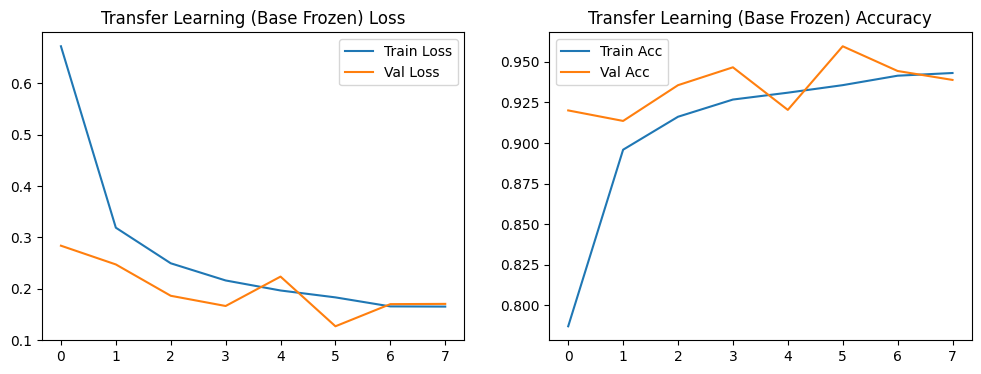

In [19]:
callbacks_tl = [
    callbacks.ModelCheckpoint("models/disease_transfer_base.h5", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history_tl = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8
)

plot_history(history_tl, "Transfer Learning (Base Frozen)")


Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 298s 597ms/step - accuracy: 0.8003 - loss: 0.6140 - val_accuracy: 0.9174 - val_loss: 0.2410
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 534ms/step - accuracy: 0.8910 - loss: 0.3075 - val_accuracy: 0.9333 - val_loss: 0.1956
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 240s 531ms/step - accuracy: 0.9132 - loss: 0.2459 - val_accuracy: 0.9404 - val_loss: 0.1721
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 533ms/step - accuracy: 0.9323 - loss: 0.2025 - val_accuracy: 0.9440 - val_loss: 0.1569
Epoch 5/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 244s 540ms/step - accuracy: 0.9389 - loss: 0.1814 - val_accuracy: 0.9531 - val_loss: 0.1376
Epoch 6/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 244s 539ms/step - accuracy: 0.9420 - loss: 0.1719 - val_accuracy: 0.9573 - val_loss: 0.1264
Epoch 7/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 243s 539ms/step - accuracy: 0.9462 - loss: 0.1535 - val_accuracy: 0.9605 - val_loss: 0.1216
Epoch 8/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 241s 533ms/step - accuracy: 0.9517 -

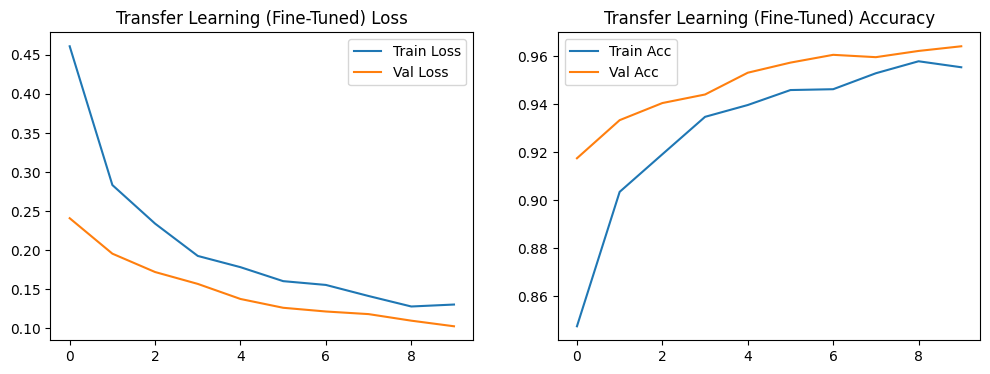

In [20]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(optimizer=optimizers.Adam(1e-5),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])

callbacks_ft = [
    callbacks.ModelCheckpoint("models/disease_transfer_finetuned.h5", save_best_only=True),
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
]

history_ft = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

plot_history(history_ft, "Transfer Learning (Fine-Tuned)")


In [24]:
#Now i just overwrite the same file for model save.

transfer_model.save("models/disease_cnn.h5")
print("CNN model saved successfully!")


CNN model saved successfully!


In [25]:
best_transfer = tf.keras.models.load_model("models/disease_cnn.h5")

test_steps = test_generator.samples // test_generator.batch_size + 1
pred = best_transfer.predict(test_generator, steps=test_steps)
y_pred = np.argmax(pred, axis=1)

print("Transfer Model Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=train_generator.class_indices.keys()))


98/98 ━━━━━━━━━━━━━━━━━━━━ 38s 332ms/step
Transfer Model Accuracy: 0.8240591830170473
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.82      0.97      0.89       151
                     Pepper__bell___healthy       0.93      1.00      0.96       223
                      Potato___Early_blight       0.99      0.85      0.91       150
                       Potato___Late_blight       0.81      1.00      0.89       150
                           Potato___healthy       0.89      0.67      0.76        24
                      Tomato_Bacterial_spot       0.93      0.86      0.89       320
                        Tomato_Early_blight       1.00      0.33      0.50       150
                         Tomato_Late_blight       0.87      0.90      0.88       287
                           Tomato_Leaf_Mold       0.83      0.86      0.85       144
                  Tomato_Septoria_leaf_spot       0.67      0.9